<h1>Project: <b>United Kingdom Road Accident Data Analysis</b></h1>
<h3>Inclusive years: 2019-2022</h3>

<h4>Analyst: John Xyril B. Cabana</h4>

In [1]:
pip install numpy pandas seaborn matplotlib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: C:\Users\LAB4-StudentPC21\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


<h2>IMPORTING LIBRARIES</h2>

In [2]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [3]:
accident = pd.read_csv('Datasets\\accident_data.csv')

<H1>DATA PREPARATION</H1>

In [4]:
accident

,Index,Accident_Severity,Accident Date,Latitude,Light_Conditions,District Area,Longitude,Number_of_Casualties,Number_of_Vehicles,Road_Surface_Conditions,Road_Type,Urban_or_Rural_Area,Weather_Conditions,Vehicle_Type
0,200701BS64157,Serious,05/06/2019,51.506187,Darkness - lights lit,Kensington and Chelsea,-0.209082,1,2,Dry,Single carriageway,Urban,Fine no high winds,Car
1,200701BS65737,Serious,02/07/2019,51.495029,Daylight,Kensington and Chelsea,-0.173647,1,2,Wet or damp,Single carriageway,Urban,Raining no high winds,Car
2,200701BS66127,Serious,26/08/2019,51.517715,Darkness - lighting unknown,Kensington and Chelsea,-0.210215,1,3,Dry,NaN,Urban,NaN,Taxi/Private hire car
3,200701BS66128,Serious,16/08/2019,51.495478,Daylight,Kensington and Chelsea,-0.202731,1,4,Dry,Single carriageway,Urban,Fine no high winds,Bus or coach (17 or more pass seats)
4,200701BS66837,Slight,03/09/2019,51.488576,Darkness - lights lit,Kensington and Chelsea,-0.192487,1,2,Dry,NaN,Urban,NaN,Other vehicle
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
660674,201091NM01760,Slight,18/02/2022,57.374005,Daylight,Highland,-3.467828,2,1,Dry,Single carriageway,Rural,Fine no high winds,Car
660675,201091NM01881,Slight,21/02/2022,57.232273,Darkness - no lighting,Highland,-3.809281,1,1,Frost or ice,Single carriageway,Rural,Fine no high winds,Car
660676,201091NM01935,Slight,23/02/2022,57.585044,Daylight,Highland,-3.862727,1,3,Frost or ice,Single carriageway,Rural,Fine no high winds,Car
660677,201091NM01964,Serious,23/02/2022,57.214898,Darkness - no lighting,Highland,-3.823997,1,2,Wet or damp,Single carriageway,Rural,Fine no high winds,Motorcycle over 500cc


In [5]:
accident.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 660679 entries, 0 to 660678
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Index                    660679 non-null  object 
 1   Accident_Severity        660679 non-null  object 
 2   Accident Date            660679 non-null  object 
 3   Latitude                 660654 non-null  float64
 4   Light_Conditions         660679 non-null  object 
 5   District Area            660679 non-null  object 
 6   Longitude                660653 non-null  float64
 7   Number_of_Casualties     660679 non-null  int64  
 8   Number_of_Vehicles       660679 non-null  int64  
 9   Road_Surface_Conditions  659953 non-null  object 
 10  Road_Type                656159 non-null  object 
 11  Urban_or_Rural_Area      660664 non-null  object 
 12  Weather_Conditions       646551 non-null  object 
 13  Vehicle_Type             660679 non-null  object 
dtypes: f

In [54]:
accident.describe().T

,count,mean,min,25%,50%,75%,max,std
Accident Date,660679,2020-11-30 08:30:32.761749760,2019-01-01 00:00:00,2019-11-27 00:00:00,2020-11-13 00:00:00,2021-11-17 00:00:00,2022-12-31 00:00:00,NaN
Number_of_Casualties,660679.0,1.35704,1.0,1.0,1.0,1.0,68.0,0.824847
Number_of_Vehicles,660679.0,1.831255,1.0,1.0,2.0,2.0,32.0,0.715269
Year,660679.0,2020.40909,2019.0,2019.0,2020.0,2021.0,2022.0,1.109152
Month,660679.0,6.607965,1.0,4.0,7.0,10.0,12.0,3.420701
Day,660679.0,15.58135,1.0,8.0,16.0,23.0,31.0,8.764863
DayofWeek,660679.0,3.111195,0.0,1.0,3.0,5.0,6.0,1.927284


<h4>Data Cleansing </h4>

In [55]:
accident.isnull().sum()

Index                      0
Accident_Severity          0
Accident Date              0
Latitude                   0
Light_Conditions           0
District Area              0
Longitude                  0
Number_of_Casualties       0
Number_of_Vehicles         0
Road_Surface_Conditions    0
Road_Type                  0
Urban_or_Rural_Area        0
Weather_Conditions         0
Vehicle_Type               0
Year                       0
Month                      0
Day                        0
DayofWeek                  0
dtype: int64

In [56]:
accident['Latitude'] = accident['Latitude'].fillna(accident['Latitude'].mode()[0])
accident['Longitude'] = accident['Longitude'].fillna(accident['Longitude'].mode()[0])
accident['Road_Surface_Conditions'] = accident['Road_Surface_Conditions'].fillna('unknown surface condition')
accident['Road_Type'] = accident['Road_Type'].fillna('unaccounted')
accident['Weather_Conditions'] = accident['Weather_Conditions'].fillna('unaccounted weather conditions')
accident['Urban_or_Rural_Area'] = accident['Urban_or_Rural_Area'].fillna(accident['Urban_or_Rural_Area'].mode()[0])

TypeError: Cannot setitem on a Categorical with a new category (unaccounted), set the categories first

In [57]:
accident.isnull().sum()

Index                      0
Accident_Severity          0
Accident Date              0
Latitude                   0
Light_Conditions           0
District Area              0
Longitude                  0
Number_of_Casualties       0
Number_of_Vehicles         0
Road_Surface_Conditions    0
Road_Type                  0
Urban_or_Rural_Area        0
Weather_Conditions         0
Vehicle_Type               0
Year                       0
Month                      0
Day                        0
DayofWeek                  0
dtype: int64

<h3> Converting Object Data type to Date Time Data Type </h3>

In [58]:
#column
#date format
#just in case errors appears
accident['Accident Date'] = pd.to_datetime(accident['Accident Date'], dayfirst = True, errors = 'coerce')

In [59]:
accident.isnull().sum()

Index                      0
Accident_Severity          0
Accident Date              0
Latitude                   0
Light_Conditions           0
District Area              0
Longitude                  0
Number_of_Casualties       0
Number_of_Vehicles         0
Road_Surface_Conditions    0
Road_Type                  0
Urban_or_Rural_Area        0
Weather_Conditions         0
Vehicle_Type               0
Year                       0
Month                      0
Day                        0
DayofWeek                  0
dtype: int64

In [60]:
# #remove any spaces 
# accident['Accident Date'] = accident['Accident Date'].str.strip()
# #convert everything from / (slash ) to - (dash)
# accident['Accident Date'] = accident['Accident Date'].str.replace('/', '-')

In [61]:
accident['Accident Date'] = pd.to_datetime(accident['Accident Date'], dayfirst = True, errors = 'coerce')

<h4>Adjusting Data types </h4>
<hr>

In [62]:
accident.dtypes

Index                            category
Accident_Severity                category
Accident Date              datetime64[ns]
Latitude                         category
Light_Conditions                 category
District Area                    category
Longitude                        category
Number_of_Casualties                int64
Number_of_Vehicles                  int64
Road_Surface_Conditions            object
Road_Type                        category
Urban_or_Rural_Area              category
Weather_Conditions                 object
Vehicle_Type                       object
Year                                int32
Month                               int32
Day                                 int32
DayofWeek                           int32
dtype: object

<h5>Categorical Data Fields</h5>

In [63]:
accident['Accident_Severity'] =accident['Accident_Severity'].astype('category')
accident['Latitude'] = accident['Latitude'].astype('category')
accident['Light_Conditions'] = accident['Light_Conditions'].astype('category')
accident['District Area'] = accident['District Area'].astype('category')
accident['Longitude'] = accident['Longitude'].astype('category')
accident['Road_Surface_Conditions'] = accident['Road_Surface_Conditions'].astype('category')
accident['Road_Type'] = accident['Road_Type'].astype('category')
accident['Urban_or_Rural_Area'] = accident['Urban_or_Rural_Area'].astype('category')
accident['Weather_Conditions'] = accident['Weather_Conditions'].astype('category')
accident['Vehicle_Type'] = accident['Vehicle_Type'].astype('category')

accident.dtypes

<h5>Converting Date to an actual Date Data Type</h5>

In [66]:
accident.isnull().sum()

Index                      0
Accident_Severity          0
Accident Date              0
Latitude                   0
Light_Conditions           0
District Area              0
Longitude                  0
Number_of_Casualties       0
Number_of_Vehicles         0
Road_Surface_Conditions    0
Road_Type                  0
Urban_or_Rural_Area        0
Weather_Conditions         0
Vehicle_Type               0
Year                       0
Month                      0
Day                        0
DayofWeek                  0
dtype: int64

<h3>Extracting date information using pandas date time </h3>

In [96]:
accident['Year'] = accident['Accident Date'].dt.year
accident['Month'] = accident['Accident Date'].dt.month
accident['Day'] = accident['Accident Date'].dt.day
accident['DayOfWeek'] = accident['Accident Date'].dt.dayofweek  # Monday=0, Sunday=6

In [69]:
accident.isnull().sum()

Index                      0
Accident_Severity          0
Accident Date              0
Latitude                   0
Light_Conditions           0
District Area              0
Longitude                  0
Number_of_Casualties       0
Number_of_Vehicles         0
Road_Surface_Conditions    0
Road_Type                  0
Urban_or_Rural_Area        0
Weather_Conditions         0
Vehicle_Type               0
Year                       0
Month                      0
Day                        0
DayofWeek                  0
dtype: int64

<h1> Data Analytics </h1>
<h4> Analyzing Each Field from the Data set</h4>

<h2> UniVariate </h2>

In [71]:
df_2019 = accident[accident['Year'] == 2019]

In [72]:
df_2019

,Index,Accident_Severity,Accident Date,Latitude,Light_Conditions,District Area,Longitude,Number_of_Casualties,Number_of_Vehicles,Road_Surface_Conditions,Road_Type,Urban_or_Rural_Area,Weather_Conditions,Vehicle_Type,Year,Month,Day,DayofWeek
0,200701BS64157,Serious,2019-06-05,51.506187,Darkness - lights lit,Kensington and Chelsea,-0.209082,1,2,Dry,Single carriageway,Urban,Fine no high winds,Car,2019,6,5,2
1,200701BS65737,Serious,2019-07-02,51.495029,Daylight,Kensington and Chelsea,-0.173647,1,2,Wet or damp,Single carriageway,Urban,Raining no high winds,Car,2019,7,2,1
2,200701BS66127,Serious,2019-08-26,51.517715,Darkness - lighting unknown,Kensington and Chelsea,-0.210215,1,3,Dry,Single carriageway,Urban,unknown,Taxi/Private hire car,2019,8,26,0
3,200701BS66128,Serious,2019-08-16,51.495478,Daylight,Kensington and Chelsea,-0.202731,1,4,Dry,Single carriageway,Urban,Fine no high winds,Bus or coach (17 or more pass seats),2019,8,16,4
4,200701BS66837,Slight,2019-09-03,51.488576,Darkness - lights lit,Kensington and Chelsea,-0.192487,1,2,Dry,Single carriageway,Urban,unknown,Other vehicle,2019,9,3,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
182110,2.01E+12,Slight,2019-12-20,54.985289,Darkness - no lighting,Dumfries and Galloway,-3.210294,1,1,Frost or ice,Single carriageway,Rural,Other,Car,2019,12,20,4
182111,2.01E+12,Serious,2019-12-21,54.984105,Daylight,Dumfries and Galloway,-3.193693,2,1,Frost or ice,Single carriageway,Rural,Other,Car,2019,12,21,5
182112,2.01E+12,Slight,2019-12-23,55.166369,Darkness - no lighting,Dumfries and Galloway,-2.992068,1,1,Frost or ice,Single carriageway,Rural,Fog or mist,Van / Goods 3.5 tonnes mgw or under,2019,12,23,0
182113,2.01E+12,Slight,2019-12-23,54.995154,Darkness - lights lit,Dumfries and Galloway,-3.058338,1,1,Wet or damp,Single carriageway,Rural,Fine no high winds,Car,2019,12,23,0


<h3>Univariate Analysis from year 2019 </h3>
<h3> Question How many accidents happened under light conditions in 2019</h3>

In [73]:
df_2019['Light_Conditions'].value_counts().sum()

np.int64(182115)

In [74]:
df_2019['Light_Conditions'].value_counts()

Light_Conditions
Daylight                       133042
Darkness - lights lit           35769
Darkness - no lighting          10842
Darkness - lighting unknown      1768
Darkness - lights unlit           694
Name: count, dtype: int64

<h1>Accidents per year</h1>

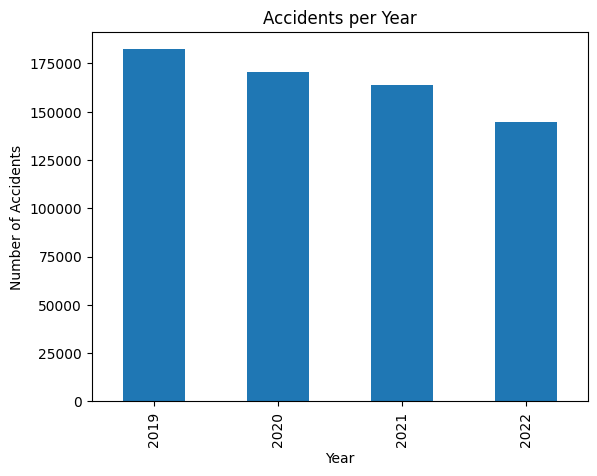

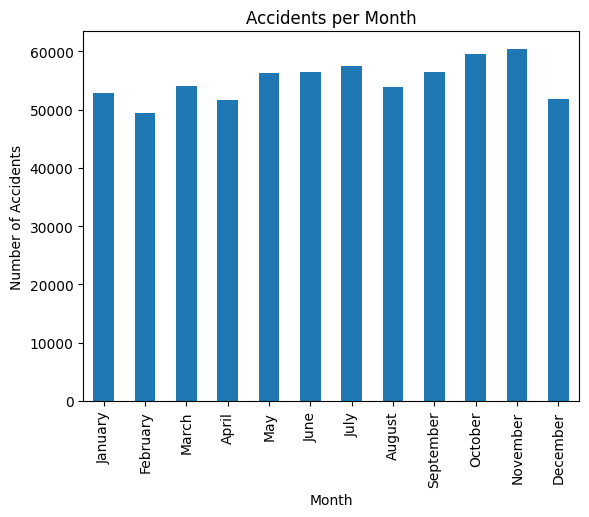

In [75]:
# Accidents per year
accidents_per_year = accident['Year'].value_counts().sort_index()

#FLoat might be caused of values without year 
accident = accident.dropna(subset=['Year'])  # Drops NaN rows but keeps DataFrame

# Accidents per month
accidents_per_month = accident['Month'].value_counts().sort_index()



accidents_per_year.plot(kind='bar')
plt.title('Accidents per Year')
plt.xlabel('Year')
plt.ylabel('Number of Accidents')
plt.show()


month_names = {
    1: 'January', 2: 'February', 3: 'March', 4: 'April',
    5: 'May', 6: 'June', 7: 'July', 8: 'August',
    9: 'September', 10: 'October', 11: 'November', 12: 'December'
}

# Replace numerical months with their names
accidents_per_month.index = accidents_per_month.index.map(month_names)

accidents_per_month.plot(kind='bar')
plt.title('Accidents per Month')
plt.xlabel('Month')
plt.ylabel('Number of Accidents')
plt.show()



In [76]:
accidents_per_year.index

Index([2019, 2020, 2021, 2022], dtype='int32', name='Year')

In [77]:
accidents_per_month.index

Index(['January', 'February', 'March', 'April', 'May', 'June', 'July',
       'August', 'September', 'October', 'November', 'December'],
      dtype='object', name='Month')

<h1> Seasonal Analysis </h1>

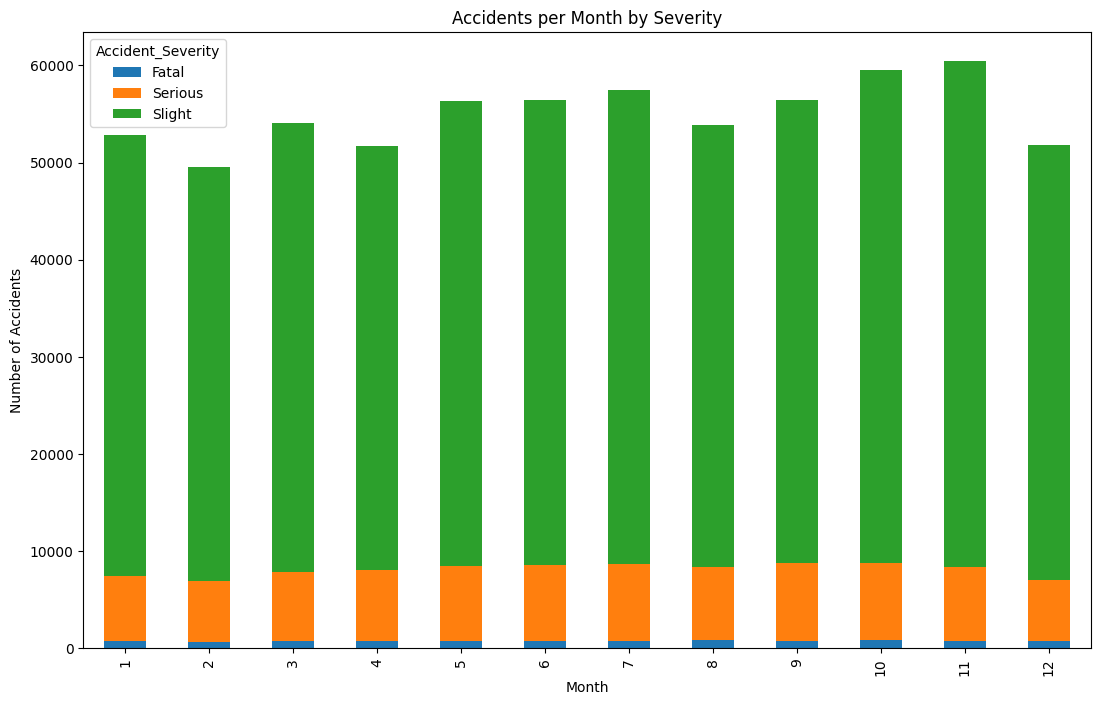

In [78]:
# Accidents per month considering severity
accidents_per_month_severity = accident.groupby(['Month', 'Accident_Severity']).size().unstack().fillna(0)

accidents_per_month_severity.plot(kind='bar', stacked=True)
plt.title('Accidents per Month by Severity')
plt.xlabel('Month')
plt.ylabel('Number of Accidents')
plt.gcf().set_size_inches(13,8)
plt.show()


In [81]:
accidentS = accident.groupby(['Month', 'Accident_Severity']).size().unstack()

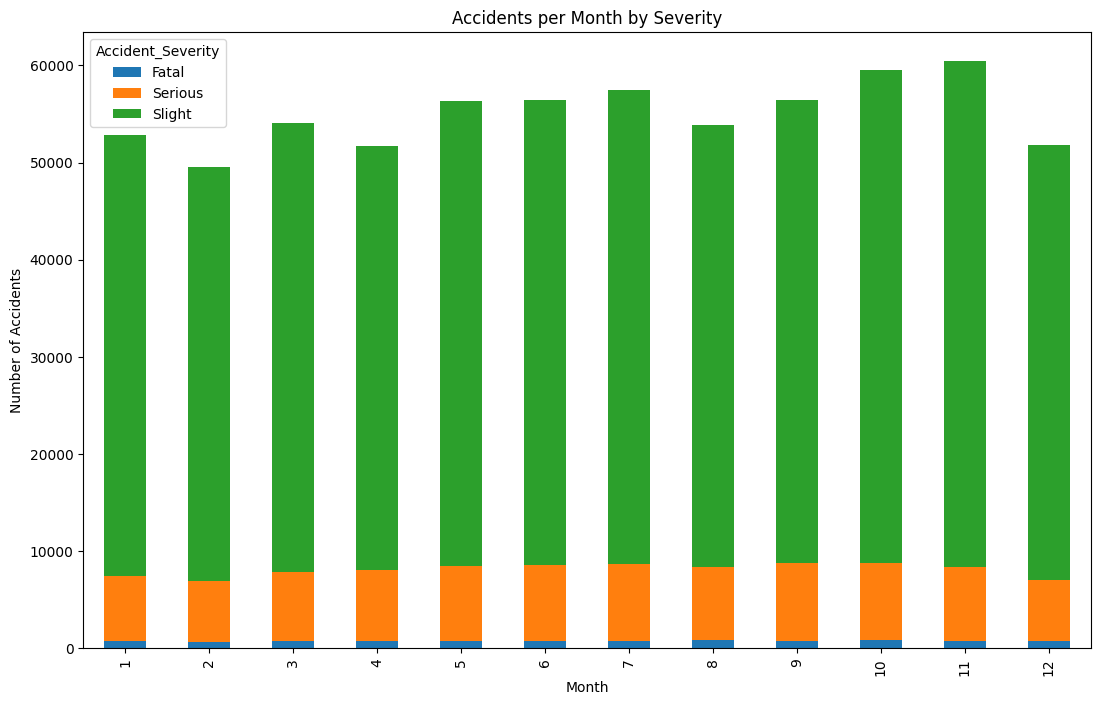

In [82]:
accidentS.plot(kind='bar', stacked=True)
plt.title('Accidents per Month by Severity')
plt.xlabel('Month')
plt.ylabel('Number of Accidents')
plt.gcf().set_size_inches(13,8)
plt.show()

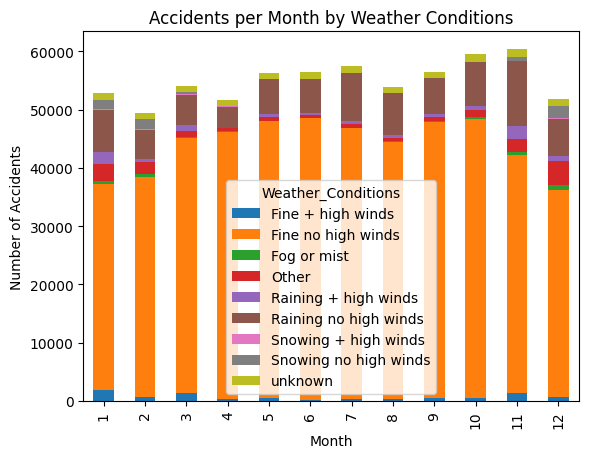

In [83]:
# Pivot table for accidents by month and weather conditions
accidents_by_month_weather = accident.pivot_table(index='Month', columns='Weather_Conditions', values='Index', aggfunc='count')

accidents_by_month_weather.plot(kind='bar', stacked=True)
plt.title('Accidents per Month by Weather Conditions')
plt.xlabel('Month')
plt.ylabel('Number of Accidents')
plt.show()


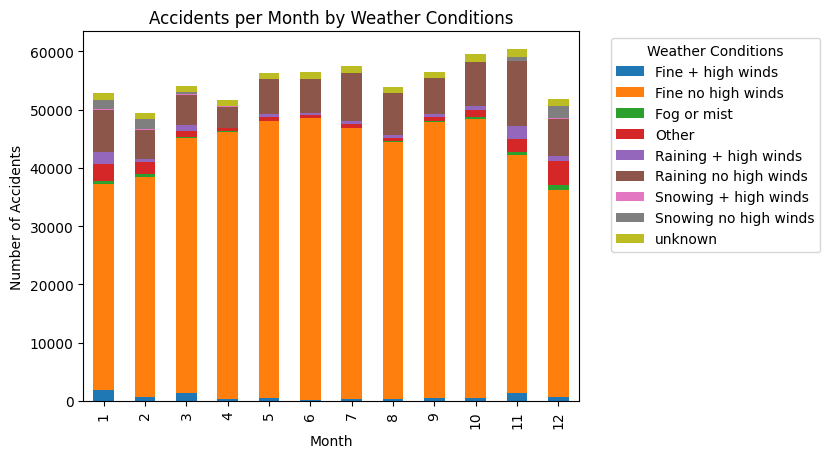

In [84]:
accident_weather = accident.groupby(["Month","Weather_Conditions"]).size().unstack()

accident_weather.plot(kind='bar', stacked=True)
plt.title('Accidents per Month by Weather Conditions')
plt.xlabel('Month')
plt.ylabel('Number of Accidents')
plt.legend(title='Weather Conditions', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [87]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Ensure the data is sorted by date
df = accident.sort_values('Accident Date')

# Set the date as the index
df.set_index('Accident Date', inplace=True)

# Resample to monthly data
monthly_accidents = df.resample('M').size()

# Decompose the time series
decomposition = seasonal_decompose(monthly_accidents, model='additive')
decomposition.plot()
plt.show()


ModuleNotFoundError: No module named 'statsmodels'

In [88]:
accident['Longitude'] = accident['Longitude'].fillna(accident['Longitude'].mode()[0])

In [89]:
pip install folium

Defaulting to user installation because normal site-packages is not writeableNote: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: C:\Users\LAB4-StudentPC21\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [90]:
!pip install folium

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: C:\Users\LAB4-StudentPC21\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [91]:
import folium
from folium.plugins import HeatMap

# Step 1: Extract latitude and longitude from the DataFrame
locations = list(zip(accident['Latitude'], accident['Longitude']))

# Step 2: Create a base map centered on a specific location
# You can adjust the center and zoom level based on your data
m = folium.Map(location=[accident['Latitude'].mean(), accident['Longitude'].mean()], zoom_start=10)

# Step 3: Add the heatmap layer
HeatMap(locations).add_to(m)

# Step 4: Save or display the map
m.save('accident_heatmap.html')  # Save the map as an HTML file
m  # Display the map in a Jupyter Notebook

TypeError: 'Categorical' with dtype category does not support reduction 'mean'

In [ ]:
accident['Latitude'] = accident['Latitude'].fillna(accident['Latitude'].mode()[0])

In [92]:
accident.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 660679 entries, 0 to 660678
Data columns (total 18 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   Index                    660679 non-null  category      
 1   Accident_Severity        660679 non-null  category      
 2   Accident Date            660679 non-null  datetime64[ns]
 3   Latitude                 660679 non-null  category      
 4   Light_Conditions         660679 non-null  category      
 5   District Area            660679 non-null  category      
 6   Longitude                660679 non-null  category      
 7   Number_of_Casualties     660679 non-null  int64         
 8   Number_of_Vehicles       660679 non-null  int64         
 9   Road_Surface_Conditions  660679 non-null  category      
 10  Road_Type                660679 non-null  category      
 11  Urban_or_Rural_Area      660679 non-null  category      
 12  Weather_Conditio

In [93]:
accident.isnull().sum()

Index                      0
Accident_Severity          0
Accident Date              0
Latitude                   0
Light_Conditions           0
District Area              0
Longitude                  0
Number_of_Casualties       0
Number_of_Vehicles         0
Road_Surface_Conditions    0
Road_Type                  0
Urban_or_Rural_Area        0
Weather_Conditions         0
Vehicle_Type               0
Year                       0
Month                      0
Day                        0
DayofWeek                  0
dtype: int64

<h2> MultiVariate </h2>

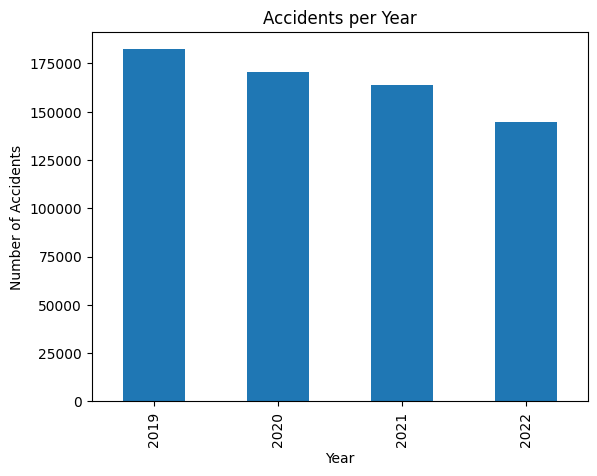

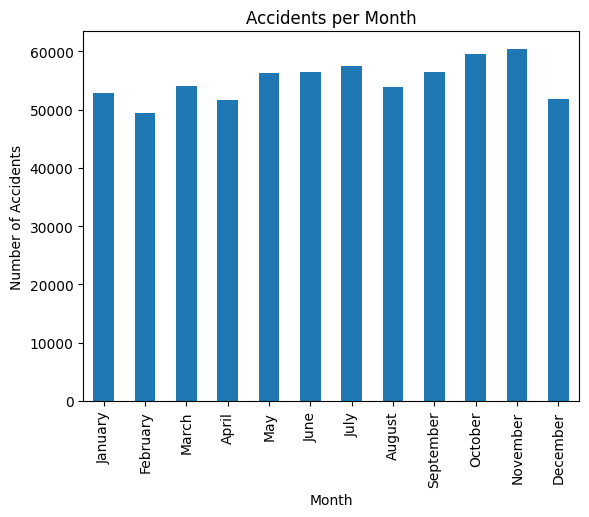

DayOfWeek
Monday        72680
Tuesday       94550
Wednesday     99558
Thursday      99511
Friday        97900
Saturday     107178
Sunday        89302
Name: count, dtype: int64


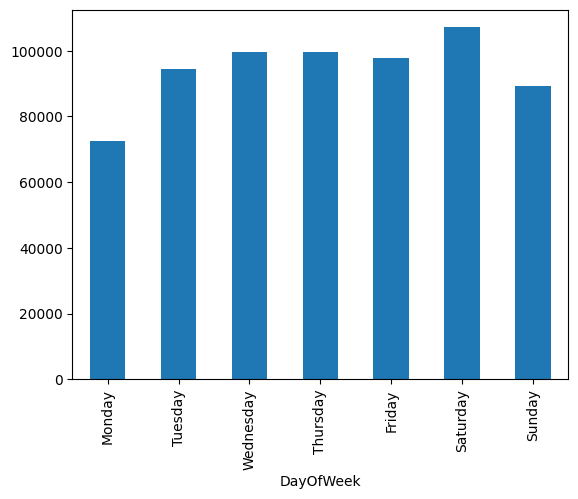

In [97]:
# Accidents per year
accidents_per_year = accident['Year'].value_counts().sort_index()

#FLoat might be caused of values without year 
# accident = accident['Year'].dropna()
# Accidents per month
accidents_per_month = accident['Month'].value_counts().sort_index()


accidents_per_year.plot(kind='bar')
plt.title('Accidents per Year')
plt.xlabel('Year')
plt.ylabel('Number of Accidents')
plt.show()


month_names = {
    1: 'January', 2: 'February', 3: 'March', 4: 'April',
    5: 'May', 6: 'June', 7: 'July', 8: 'August',
    9: 'September', 10: 'October', 11: 'November', 12: 'December'
}

# Replace numerical months with their names
accidents_per_month.index = accidents_per_month.index.map(month_names)


accidents_per_month.plot(kind='bar')
plt.title('Accidents per Month')
plt.xlabel('Month')
plt.ylabel('Number of Accidents')
plt.show()

accidents_per_day = accident['DayOfWeek'].value_counts().sort_index()
#accident per day
day_names = {
    0: 'Monday',
    1: 'Tuesday',
    2: 'Wednesday',
    3: 'Thursday',
    4: 'Friday',
    5: 'Saturday',
    6: 'Sunday'
}

accidents_per_day.index = accidents_per_day.index.map(day_names)
accidents_per_day.plot(kind='bar')
print(accidents_per_day)

<h4> DATA AGGREGATION </h4>

In [99]:
Severity = accident.groupby("Accident_Severity").count()

In [100]:
Severity

,Index,Accident Date,Latitude,Light_Conditions,District Area,Longitude,Number_of_Casualties,Number_of_Vehicles,Road_Surface_Conditions,Road_Type,Urban_or_Rural_Area,Weather_Conditions,Vehicle_Type,Year,Month,Day,DayofWeek,DayOfWeek
Accident_Severity,,,,,,,,,,,,,,,,,,
Fatal,8661,8661,8661,8661,8661,8661,8661,8661,8661,8661,8661,8661,8661,8661,8661,8661,8661,8661
Serious,88217,88217,88217,88217,88217,88217,88217,88217,88217,88217,88217,88217,88217,88217,88217,88217,88217,88217
Slight,563801,563801,563801,563801,563801,563801,563801,563801,563801,563801,563801,563801,563801,563801,563801,563801,563801,563801


In [101]:
Severity2 = accident.groupby("Accident_Severity")["Road_Type"].count()

In [102]:
Severity2

Accident_Severity
Fatal        8661
Serious     88217
Slight     563801
Name: Road_Type, dtype: int64

In [103]:
Severity3 = pd.DataFrame(Severity2)

In [104]:
print(type(Severity3))

<class 'pandas.core.frame.DataFrame'>


In [105]:
Severity3

,Road_Type
Accident_Severity,
Fatal,8661
Serious,88217
Slight,563801


In [106]:
accident.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 660679 entries, 0 to 660678
Data columns (total 19 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   Index                    660679 non-null  category      
 1   Accident_Severity        660679 non-null  category      
 2   Accident Date            660679 non-null  datetime64[ns]
 3   Latitude                 660679 non-null  category      
 4   Light_Conditions         660679 non-null  category      
 5   District Area            660679 non-null  category      
 6   Longitude                660679 non-null  category      
 7   Number_of_Casualties     660679 non-null  int64         
 8   Number_of_Vehicles       660679 non-null  int64         
 9   Road_Surface_Conditions  660679 non-null  category      
 10  Road_Type                660679 non-null  category      
 11  Urban_or_Rural_Area      660679 non-null  category      
 12  Weather_Conditio

In [107]:
accident.dtypes

Index                            category
Accident_Severity                category
Accident Date              datetime64[ns]
Latitude                         category
Light_Conditions                 category
District Area                    category
Longitude                        category
Number_of_Casualties                int64
Number_of_Vehicles                  int64
Road_Surface_Conditions          category
Road_Type                        category
Urban_or_Rural_Area              category
Weather_Conditions               category
Vehicle_Type                     category
Year                                int32
Month                               int32
Day                                 int32
DayofWeek                           int32
DayOfWeek                           int32
dtype: object

In [108]:
accident['Year'] = accident['Accident Date'].dt.year
accident['Month'] = accident['Accident Date'].dt.month
accident['Day'] = accident['Accident Date'].dt.day
accident['DayOfWeek'] = accident['Accident Date'].dt.dayofweek  # Monday=0, Sunday=6

<h3>Converting Object to DateTime Data Type</h3>

In [10]:
accident['Accident Date'] = pd.to_datetime(accident['Accident Date'] , dayfirst = True, errors = 'coerce')

In [11]:
accident.dtypes

Index                              object
Accident_Severity                category
Accident Date              datetime64[ns]
Latitude                          float64
Light_Conditions                   object
District Area                      object
Longitude                         float64
Number_of_Casualties                int64
Number_of_Vehicles                  int64
Road_Surface_Conditions            object
Road_Type                          object
Urban_or_Rural_Area                object
Weather_Conditions                 object
Vehicle_Type                       object
dtype: object

In [12]:
accident.isnull().sum()

Index                          0
Accident_Severity              0
Accident Date                  0
Latitude                      25
Light_Conditions               0
District Area                  0
Longitude                     26
Number_of_Casualties           0
Number_of_Vehicles             0
Road_Surface_Conditions      726
Road_Type                   4520
Urban_or_Rural_Area           15
Weather_Conditions         14128
Vehicle_Type                   0
dtype: int64

In [13]:
accident['Latitude'] = accident['Latitude'].fillna(accident['Latitude'].mode()[0])
accident['Longitude'] = accident['Longitude'].fillna(accident['Longitude'].mode()[0])
accident['Road_Surface_Conditions'] = accident['Road_Surface_Conditions'].fillna('unknown')
accident['Road_Type'] = accident['Road_Type'].fillna(accident['Road_Type'].mode()[0])
accident['Urban_or_Rural_Area'] = accident['Urban_or_Rural_Area'].fillna(accident['Urban_or_Rural_Area'].mode()[0])
accident['Weather_Conditions'] = accident['Weather_Conditions'].fillna('unknown')

In [14]:
accident['Year'] = accident['Accident Date'].dt.year
accident['Month'] = accident['Accident Date'].dt.month
accident['Day'] = accident['Accident Date'].dt.day
accident['DayofWeek'] = accident['Accident Date'].dt.dayofweek

In [112]:
accident['Index'] = accident['Index'].astype('category')
accident['Light_Conditions'] = accident['Light_Conditions'].astype('category')
accident['Latitude'] = accident['Latitude'].astype('category')
accident['Longitude'] = accident['Longitude'].astype('category')
accident['District Area'] = accident['District Area'].astype('category')
accident['Road_Type'] = accident['Road_Type'].astype('category')
accident['Urban_or_Rural_Area'] = accident['Urban_or_Rural_Area'].astype('category')
accident['Year'] = accident['Year'].astype('category')
accident['Month'] = accident['Month'].astype('category')
accident['Day'] = accident['Day'].astype('category')
accident['DayofWeek'] = accident['DayofWeek'].astype('category')

In [16]:
accident.dtypes

Index                            category
Accident_Severity                category
Accident Date              datetime64[ns]
Latitude                         category
Light_Conditions                 category
District Area                    category
Longitude                        category
Number_of_Casualties                int64
Number_of_Vehicles                  int64
Road_Surface_Conditions            object
Road_Type                        category
Urban_or_Rural_Area              category
Weather_Conditions                 object
Vehicle_Type                       object
Year                             category
Month                            category
Day                              category
DayofWeek                        category
dtype: object

In [17]:
accident.isnull().sum()

Index                      0
Accident_Severity          0
Accident Date              0
Latitude                   0
Light_Conditions           0
District Area              0
Longitude                  0
Number_of_Casualties       0
Number_of_Vehicles         0
Road_Surface_Conditions    0
Road_Type                  0
Urban_or_Rural_Area        0
Weather_Conditions         0
Vehicle_Type               0
Year                       0
Month                      0
Day                        0
DayofWeek                  0
dtype: int64

In [18]:
accident['Year'] = accident['Accident Date'].dt.year
accident['Month'] = accident['Accident Date'].dt.month
accident['Day'] = accident['Accident Date'].dt.day
accident['DayofWeek'] = accident['Accident Date'].dt.dayofweek

<h1># Univariate Analysis on accident that happened in 2019</h1>

In [110]:
df_2019 = accident[accident['Accident_Severity'] == 2019]

In [111]:
print(f"total number of accident in 2019 is {df_2019['Light_Conditions'].value_counts().sum()}")
df_2019['Light_Conditions'].value_counts()

total number of accident in 2019 is 0


Light_Conditions
Darkness - lighting unknown    0
Darkness - lights lit          0
Darkness - lights unlit        0
Darkness - no lighting         0
Daylight                       0
Name: count, dtype: int64

In [126]:
# Assuming there's a 'Date' column in the dataset
df['Year'] = pd.to_datetime(df['Month']).dt.year

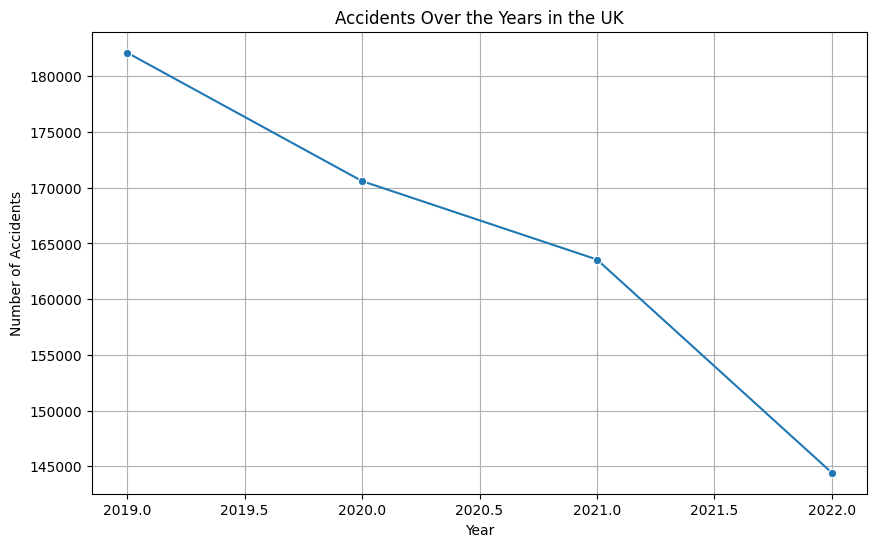

In [131]:
# Group by Year and count the accidents
accidents_by_year = accident.groupby('Year').size()

plt.figure(figsize=(10,6))
sns.lineplot(x=accidents_by_year.index, y=accidents_by_year.values, marker='o')
plt.title('Accidents Over the Years in the UK')
plt.ylabel('Number of Accidents')
plt.xlabel('Year')
plt.grid(True)
plt.show()


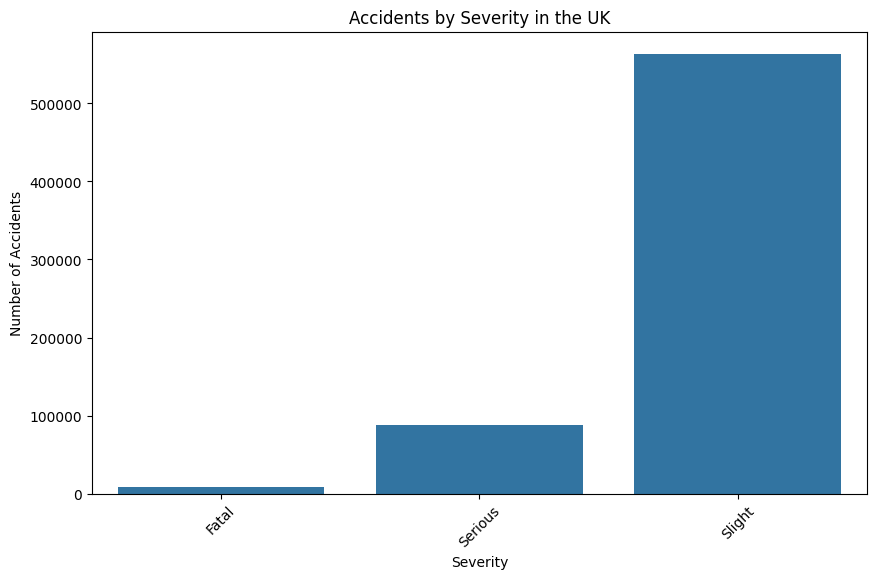

In [133]:
severity_counts = df['Accident_Severity'].value_counts()

plt.figure(figsize=(10,6))
sns.barplot(x=severity_counts.index, y=severity_counts.values)
plt.title('Accidents by Severity in the UK')
plt.xlabel('Severity')
plt.ylabel('Number of Accidents')
plt.xticks(rotation=45)
plt.show()


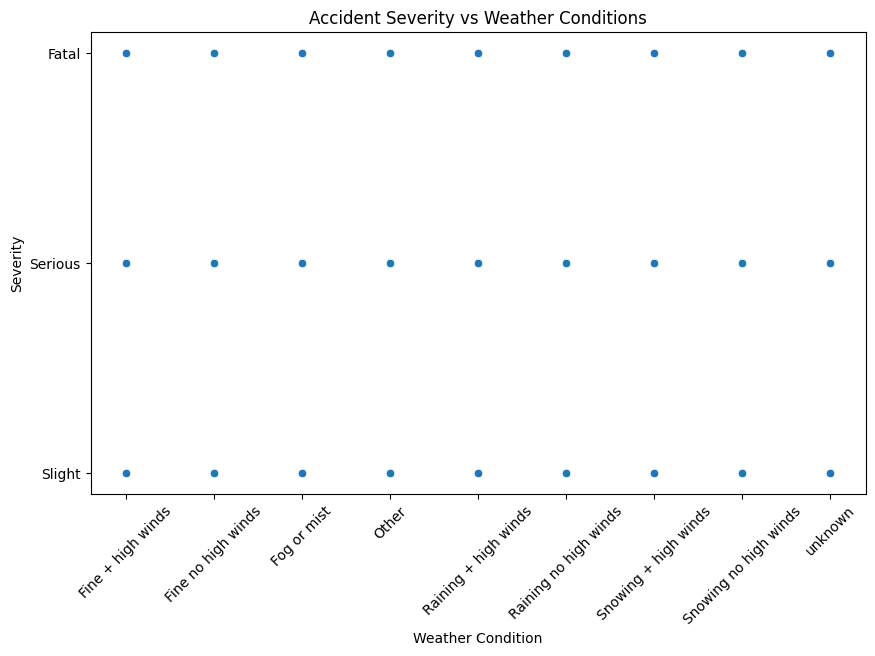

In [142]:
# Assuming 'Weather' and 'Severity' columns exist
plt.figure(figsize=(10,6))
sns.scatterplot(data=accident, x='Weather_Conditions', y='Accident_Severity')
plt.title('Accident Severity vs Weather Conditions')
plt.xlabel('Weather Condition')
plt.ylabel('Severity')
plt.xticks(rotation=45)
plt.show()

<h1 style="background-color:#47c6ce ">2019 ACCIDENT DATA</h1>

In [20]:
accident_2019 = accident[accident['Year'] == 2019]
accident_2020 = accident[accident['Year'] == 2020]
accident_2021 = accident[accident['Year'] == 2021]
accident_2022 = accident[accident['Year'] == 2022]

<h2>INSIGHT #1</h2>

<h2>Contrary to popular belief that most accident happens in darkness or at night time, majority of the accident happens on broad daylight. About73.05% of the total accidents in 2019 happened during Daylight</h2>

<h3>Further Exmination / and Analysis of 2019 Accident</h3>
<h3>Bivariat: Light Conditions and Weather Condition</h3>

In [114]:
df_2019['Weather_Conditions'].value_counts()

Weather_Conditions
Fine + high winds        0
Fine no high winds       0
Fog or mist              0
Other                    0
Raining + high winds     0
Raining no high winds    0
Snowing + high winds     0
Snowing no high winds    0
unknown                  0
Name: count, dtype: int64

<h2>INSIGHT #2</h2>
<h2>Out of the total182,115 accidents recorded, 79% (143,876) occurred under weather conditions describedas "Fine with no high winds." This suggests that even in seemingly favorable weather conditions, accidents remain highly prevalent. This highlights the need to explore other</h2>

In [115]:
casualty_2019 = df_2019.groupby(['Weather_Conditions', 'Vehicle_Type'])['Number_of_Casualties'].count()

In [116]:
df_exam3 = df_2019[df_2019['Weather_Conditions'] == 'Fine no high winds']

In [117]:
df_exam4 = df_exam3.groupby(['Vehicle_Type','Urban_or_Rural_Area'])['Number_of_Casualties'].size()

In [118]:
df_exam4.unstack()

Urban_or_Rural_Area,Rural,Unallocated,Urban
Vehicle_Type,,,
Agricultural vehicle,0,0,0
Bus or coach (17 or more pass seats),0,0,0
Car,0,0,0
Data missing or out of range,0,0,0
Goods 7.5 tonnes mgw and over,0,0,0
Goods over 3.5t. and under 7.5t,0,0,0
Minibus (8 - 16 passenger seats),0,0,0
Motorcycle 125cc and under,0,0,0
Motorcycle 50cc and under,0,0,0


In [119]:
df_exam5 =df_exam3.groupby(['Vehicle_Type','Urban_or_Rural_Area'])['Number_of_Casualties'].size()

In [120]:
df_exam5.unstack()

Urban_or_Rural_Area,Rural,Unallocated,Urban
Vehicle_Type,,,
Agricultural vehicle,0,0,0
Bus or coach (17 or more pass seats),0,0,0
Car,0,0,0
Data missing or out of range,0,0,0
Goods 7.5 tonnes mgw and over,0,0,0
Goods over 3.5t. and under 7.5t,0,0,0
Minibus (8 - 16 passenger seats),0,0,0
Motorcycle 125cc and under,0,0,0
Motorcycle 50cc and under,0,0,0


<h2>INSIGHT #3</h2>
<h2>On 2019, upon closer examination of the vehicle type accidents, most of the accident was in the vehicle type 'car', 37,652 accidents or 20% of the total accident happened on the <b>RURAL AREAS</b>.</h2>

In [121]:
average_vehicles = accident_2019['Number_of_Vehicles'].mean()
print(f"Average Number of Vehicles per Accident: {average_vehicles:.2f}")

Average Number of Vehicles per Accident: 1.84


<h2>INSIGHT #4</h2>
<h3>What is the average number of vehicles involved per accident?</h3>

<h2>About 81% of the accidents that happened on the <b>RURAL AREAS</b> under the vehicle type '<b>CAR</b>' were classified as 'slight' in term of its severity and less than 20% were <b>fatal</b> or <b>serious</b> in terms of serverity. Only about 2% ended up in 'fatal' under the vehicle type car</h2>

In [24]:
average_vehicles = accident_2019['Number_of_Vehicles'].mean()
print(f"Average Number of Vehicles per Accident: {average_vehicles:.2f}")

Average Number of Vehicles per Accident: 1.84


<h3>INSIGHT: On average, 1.84 vehicles were involved per accident, indicating that most accidents typically involve one or two vehicles, with some incidents involving additional vehicles.</h3>

<h2>INSIGHT #5</h2>
<h3>What is the distribution of accident severity based on the provided data?</h3>

<h2>In contrast, 35.8% of all 2019 accidents, or 65,248 incidents involved cars in urban areas, a notably higher figure. About 86.6% ended up in accident ended up only in 'slight' in terms of severity. Only less than 1% ended up <b>'fatal'</b> </h2>

In [25]:
severity_counts = accident_2019['Accident_Severity'].value_counts()
print(severity_counts)

Accident_Severity
Slight     155079
Serious     24322
Fatal        2714
Name: count, dtype: int64


<h3>INSIGHT: Slight accidents account for 85.16% of all incidents, while serious accidents make up 13.36%, and fatal accidents just 1.49%, showing a significant 71.8% gap between slight and serious accidents, and an even larger 83.67% difference between slight and fatal incidents.</h3>

<h2>INSIGHT #6</h2>
<h3>What are the number of accidents per month on 2019 based on the provided data?</h3>

In [26]:
monthly_accidents = accident_2019['Month'].value_counts().sort_index()
print(monthly_accidents)

Month
1     15355
2     13253
3     15049
4     14125
5     15833
6     15528
7     15862
8     15044
9     15271
10    15528
11    16559
12    14708
Name: count, dtype: int64


<h3>INSIGHT: Accidents peak in November (16,559 incidents, 9.09% of the total) and dip in February (13,253 incidents, 7.28%), with monthly fluctuations showing a general trend of higher accident rates during the warmer months.</h3>

<h2>INSIGHT #7</h2>
<h3>Which days of the week experience the highest number of accidents based on the provided data?</h3>

In [27]:
dayofweek_accidents = accident_2019['DayofWeek'].value_counts().reindex([1,2,3,4,5,6,7])
print(dayofweek_accidents)

DayofWeek
1    26251.0
2    26927.0
3    27300.0
4    27303.0
5    29262.0
6    24686.0
7        NaN
Name: count, dtype: float64


<h3>INSIGHT: Accidents peak on Fridays, accounting for 18.10% of the total, while Saturdays see the lowest frequency at 15.27% , and Mondays start the week with a moderate 16.23% , reflecting varying trends throughout the week.</h3>

In [28]:
urban_rural_counts = accident_2019['Urban_or_Rural_Area'].value_counts()
print(urban_rural_counts)

Urban_or_Rural_Area
Urban          114552
Rural           67558
Unallocated         5
Name: count, dtype: int64


<h3>INSIGHT: Urban areas account for 63.45% of all accidents (114,552 incidents), while rural areas make up 36.54% (67,558 incidents), with less than 0.01% (5 incidents) unallocated, highlighting that urban areas experience significantly more accidents than rural regions.</h3>

<h2>INSIGHT #8</h2>
<h3>Does weather condition have an impact on the number of accidents?</h3>

In [29]:
weather_counts = accident_2019['Weather_Conditions'].value_counts()
print(weather_counts)

Weather_Conditions
Fine no high winds       143876
Raining no high winds     22835
unknown                    4134
Other                      4083
Raining + high winds       2959
Fine + high winds          2545
Fog or mist                 857
Snowing no high winds       680
Snowing + high winds        146
Name: count, dtype: int64


<h3>INSIGHT: The majority of accidents occur under "Fine no high winds" conditions, accounting for 79.01% (143,876 incidents), followed by "Raining no high winds" at 12.54% (22,835 incidents), with rare conditions like "Snowing + high winds" making up only 0.08% (146 incidents), showing that most accidents happen in clear or mild weather.</h3>

<h2>INSIGHT #9</h2>
<h3>Does light condition have an impact on the number of accidents?</h3>

In [30]:
light_counts = accident_2019['Light_Conditions'].value_counts()
print(light_counts)

Light_Conditions
Daylight                       133042
Darkness - lights lit           35769
Darkness - no lighting          10842
Darkness - lighting unknown      1768
Darkness - lights unlit           694
Name: count, dtype: int64


<h3>INSIGHT: Daylight accounts for 73.06% (133,042 incidents) of all accidents, while "Darkness - lights lit" makes up 19.64% (35,769 incidents), and the least frequent condition, "Darkness - lights unlit," represents only 0.38% (694 incidents), suggesting that visibility plays a significant role in accident frequency.</h3>

<h2>INSIGHT #10</h2>
<h3>Does the road surface condition have an impact on the number of accidents?</h3>

In [31]:
road_surface_counts = accident_2019['Road_Surface_Conditions'].value_counts()
print(road_surface_counts)

Road_Surface_Conditions
Dry                     125348
Wet or damp              53153
Frost or ice              2569
Snow                       534
Flood over 3cm. deep       312
unknown                    199
Name: count, dtype: int64


<h3>INSIGHT: The majority of accidents occur on dry roads, accounting for 68.83% (125,348 incidents), followed by wet or damp conditions at 29.19% (53,153 incidents), while rare conditions like snow and flooding make up only 0.29% (534 incidents) and 0.17% (312 incidents) respectively, indicating that road surface conditions significantly influence accident likelihood.</h3>

<h2>INSIGHT #11</h2>
<h3>Does the type of vehicle involved have an impact on the number of accidents?</h3>

In [32]:
vehicle_type_counts = accident_2019['Vehicle_Type'].value_counts()
print(vehicle_type_counts)

Vehicle_Type
Car                                      130304
Bus or coach (17 or more pass seats)      10483
Van / Goods 3.5 tonnes mgw or under        9303
Motorcycle over 500cc                      7686
Goods 7.5 tonnes mgw and over              6247
Motorcycle 125cc and under                 4313
Taxi/Private hire car                      4230
Motorcycle over 125cc and up to 500cc      2446
Motorcycle 50cc and under                  2136
Goods over 3.5t. and under 7.5t            2049
Other vehicle                              1588
Agricultural vehicle                        636
Minibus (8 - 16 passenger seats)            625
Pedal cycle                                  68
Ridden horse                                  1
Name: count, dtype: int64


<h3>INSIGHT: Cars are involved in the majority of accidents, accounting for 71.56% (130,304 incidents), followed by buses or coaches at 5.76% (10,483 incidents) and vans/goods vehicles under 3.5 tonnes at 5.11% (9,303 incidents), while rare vehicle types like pedal cycles and ridden horses make up less than 0.01% (68 and 1 incident respectively), highlighting the dominance of cars in accident involvement.</h3>

<h2>INSIGHT #12</h2>
<h3>What percentage of urban accidents occurred under normal light conditions?</h3>

In [33]:
urban_dark_accidents = accident_2019[(accident_2019['Urban_or_Rural_Area'] == 'Urban') & (accident_2019['Light_Conditions'] == 'Daylight')]
print("Accidents in Urban Areas with Normal Light Conditions:")
print(len(urban_dark_accidents))

Accidents in Urban Areas with Normal Light Conditions:
83679


<h3>INSIGHT: Out of the total 114,552 urban accidents , 83,679 (73.05%) occurred under normal light conditions, indicating that the majority of urban accidents happen when visibility is not a significant factor.</h3>

<h2>INSIGHT #13</h2>
<h3>What percentage of fatal accidents occurred on dry roads?</h3>

In [34]:
fatal_wet_accidents = accident_2019[(accident_2019['Accident_Severity'] == 'Fatal') & (accident_2019['Road_Surface_Conditions'] == 'Dry')]
print("Fatal Accidents on Dry Roads:")
print(len(fatal_wet_accidents))

Fatal Accidents on Dry Roads:
1850


<h3>INSIGHT: Out of the total 2,714 fatal accidents , 1,850 (68.17%) occurred on dry roads, indicating that the majority of severe accidents happen when the road surface is dry rather than wet or slippery.</h3>

<h2>INSIGHT #14</h2>
<h3>What percentage of accidents in rural areas involved multiple vehicles?</h3>

In [35]:
rural_multi_vehicle_accidents = accident_2019[(accident_2019['Urban_or_Rural_Area'] == 'Rural') & (accident_2019['Number_of_Vehicles'] > 1)]
print("Multi-Vehicle Accidents in Rural Areas:")
print(len(rural_multi_vehicle_accidents))

Multi-Vehicle Accidents in Rural Areas:
46615


<h3>INSIGHT: Out of the total 67,558 accidents in rural areas, 46,615 (68.99%) involved multiple vehicles, indicating that multi-vehicle collisions are more common in rural settings.</h3>

<h2>INSIGHT #15</h2>
<h3>What percentage of fatal accidents occurred on dual carriageways during nighttime with lights lit?</h3>

In [36]:
fatal_dual_dark_accidents = accident_2019[
    (accident_2019['Accident_Severity'] == 'Fatal') & 
    (accident_2019['Road_Type'] == 'Dual carriageway') & 
    (accident_2019['Light_Conditions'] == 'Darkness - lights lit')]
print("Fatal Accidents on Dual carriageway with Darkness - lights lit light condition:")
print(len(fatal_dual_dark_accidents))

Fatal Accidents on Dual carriageway with Darkness - lights lit light condition:
141


<h3>INSIGHT: Out of the total 2,714 fatal accidents , 141 (5.20%) occurred on dual carriageways under the light condition "Darkness - lights lit," indicating that this specific scenario accounts for a small but notable proportion of severe accidents.</h3>

<h2>INSIGHT #16</h2>
<h3>How many accidents involving multiple vehicles occurred in urban areas on wet or damp roads?</h3>

In [37]:
rural_multi_vehicle_wet_accidents = accident_2019[
    (accident_2019['Urban_or_Rural_Area'] == 'Urban') & 
    (accident_2019['Number_of_Vehicles'] > 1) & 
    (accident_2019['Road_Surface_Conditions'] == 'Wet or damp')]
print("Multi-Vehicle Accidents in Rural Areas with Wet Roads:")
print(len(rural_multi_vehicle_wet_accidents))

Multi-Vehicle Accidents in Rural Areas with Wet Roads:
21242


<h3>INSIGHT: A total of 21,242 multi-vehicle accidents occurred in urban areas on wet roads, accounting for approximately 18.55% of all urban accidents, highlighting the increased risk of collisions under these conditions.</h3>

<h2>INSIGHT #17</h2>
<h3>How does the number of accidents vary by month and day of the week?</h3>

In [38]:
monthly_day_accidents = accident_2019.groupby(['Month', 'DayofWeek']).size().unstack()
print("Accidents by Month and Day of the Week:")
print(monthly_day_accidents)

Accidents by Month and Day of the Week:
DayofWeek     0     1     2     3     4     5     6
Month                                              
1          1427  2487  2446  2814  2223  2196  1762
2          1373  1957  1900  1991  2047  2215  1770
3          1513  1961  1983  1989  2516  2746  2341
4          1936  2398  1839  2036  2088  1962  1866
5          1747  1815  2710  2753  2603  2237  1968
6          1730  1979  2002  2215  2049  2953  2600
7          2080  2536  2598  2039  2169  2384  2056
8          1801  1772  2013  2453  2371  2589  2045
9          1988  2143  2315  2049  2077  2396  2303
10         1568  2484  2756  2581  2084  2280  1775
11         1558  2220  2439  2250  2887  3215  1990
12         1665  2499  1926  2130  2189  2089  2210


<h3>INSIGHT: Accidents tend to peak on Fridays, with November showing the highest Friday accident count (3,215 incidents ), while February has the lowest overall accident numbers, particularly on Mondays (1,957 incidents ). Sundays consistently have fewer accidents across all months, suggesting reduced traffic or activity levels.</h3>

<h2>INSIGHT #18</h2>
<h3>How does the number of fatal accidents vary by month?</h3>

In [39]:
fatal_accidents = accident_2019[accident_2019['Accident_Severity'] == 'Fatal']
fatal_monthly_accidents = fatal_accidents['Month'].value_counts().sort_index()

print("Fatal Accidents by Month:")
print(fatal_monthly_accidents)

Fatal Accidents by Month:
Month
1     239
2     173
3     212
4     231
5     230
6     201
7     225
8     260
9     225
10    245
11    238
12    235
Name: count, dtype: int64


<h3>INSIGHT: Fatal accidents are most frequent in August , accounting for 9.58% of all fatal accidents, while February has the lowest frequency at 6.37% , indicating seasonal variations in accident severity.

</h3>

<h2>INSIGHT #19</h2>
<h3>How does the total number of casualties vary by month and accident severity?</h3>

In [40]:
casualties_by_month_severity = accident_2019.groupby(['Month', 'Accident_Severity'])['Number_of_Casualties'].sum()

print("Casualties by Month and Accident Severity:")
print(casualties_by_month_severity)

Casualties by Month and Accident Severity:
Month  Accident_Severity
1      Fatal                  524
       Serious               2919
       Slight               17319
2      Fatal                  354
       Serious               2440
       Slight               15078
3      Fatal                  383
       Serious               2882
       Slight               17084
4      Fatal                  451
       Serious               3095
       Slight               15686
5      Fatal                  478
       Serious               2975
       Slight               18294
6      Fatal                  393
       Serious               3090
       Slight               17726
7      Fatal                  403
       Serious               3346
       Slight               18097
8      Fatal                  500
       Serious               3334
       Slight               17173
9      Fatal                  444
       Serious               3123
       Slight               17142
10     Fatal  

<h3>INSIGHT: Casualties peak in November , with a total of 22,134 incidents , driven primarily by slight accidents (18,582 , or 84.95% ), while February sees the lowest total casualties (17,872 ), reflecting fewer accidents across all severity levels. Fatalities remain relatively consistent month-to-month, ranging from 354 (February) to 525 (October) , indicating that seasonal factors have a greater impact on slight and serious accidents than on fatalities.</h3>

<h2>INSIGHT #20</h2>
<h3>How does the number of accidents vary by day of the week and light conditions?</h3>

In [41]:
day_light_accidents = accident_2019.groupby(['DayofWeek', 'Light_Conditions']).size()

print("Accidents by Day of the Week and Light Conditions:")
print(day_light_accidents)

Accidents by Day of the Week and Light Conditions:
DayofWeek  Light_Conditions           
0          Darkness - lighting unknown      264
           Darkness - lights lit           4986
           Darkness - lights unlit           68
           Darkness - no lighting          1540
           Daylight                       13528
1          Darkness - lighting unknown      227
           Darkness - lights lit           4825
           Darkness - lights unlit           98
           Darkness - no lighting          1409
           Daylight                       19692
2          Darkness - lighting unknown      252
           Darkness - lights lit           4602
           Darkness - lights unlit           90
           Darkness - no lighting          1452
           Daylight                       20531
3          Darkness - lighting unknown      235
           Darkness - lights lit           4662
           Darkness - lights unlit          111
           Darkness - no lighting          141

<h3>INSIGHT: Daylight accounts for the majority of accidents across all days of the week (7.43%-11.24% ), while poor light conditions such as "Darkness - lights lit" contribute significantly on weekends (up to 3.24% on Saturdays ), highlighting the impact of visibility and activity levels on accident patterns.</h3>

In [42]:
corr19 = accident_2019[['Number_of_Vehicles', 'Number_of_Casualties']].corr()
print("\nCorrelation Between Number of Vehicles and Casualties:")
print(corr19)


Correlation Between Number of Vehicles and Casualties:
                      Number_of_Vehicles  Number_of_Casualties
Number_of_Vehicles              1.000000              0.224921
Number_of_Casualties            0.224921              1.000000


<h3>INSIGHT: The weak positive correlation of 0.225 between the number of vehicles involved in an accident and the number of casualties is statistically significant (p-value ≪ 0.05) due to the large sample size of 660,679 accidents, indicating a meaningful but modest relationship where more vehicles tend to result in slightly more casualties, though other factors likely contribute significantly to casualty numbers.</h3>

In [43]:
pandemic = accident[accident['Year'].isin([2020, 2021])]

In [44]:
total_accidents_pandemic = pandemic.groupby('Year').size()
overall_total = total_accidents_pandemic.sum()
print(f"Total Accidents During the Pandemic (2020–2021): {overall_total}")
print(total_accidents_pandemic)

Total Accidents During the Pandemic (2020–2021): 334145
Year
2020    170591
2021    163554
dtype: int64


<h3>INSIGHT: The total number of accidents during the pandemic (2020–2021) was 334,145, with 170,591 in 2020 and 163,554 in 2021. This represents a 4.1% decrease from 2020 to 2021.</h3>

In [45]:
total_casualties_by_year = pandemic.groupby('Year')['Number_of_Casualties'].sum()
total_casualties_combined = total_casualties_by_year.sum()
print(f"Total Casualties During the Pandemic:{total_casualties_combined}")
print(total_casualties_by_year)

Total Casualties During the Pandemic:453051
Year
2020    230905
2021    222146
Name: Number_of_Casualties, dtype: int64


<h3>INSIGHT: The total number of casualties during the pandemic (2020–2021) was 453,051, with 230,905 in 2020 and 222,146 in 2021. This represents a 3.8% decrease from 2020 to 2021.</h3>

In [46]:
fatal_accidents = pandemic[pandemic['Accident_Severity'] == 'Fatal']
fatal_accidents_by_year = fatal_accidents.groupby('Year').size()
fatal_accidents_combined = fatal_accidents_by_year.sum()

print(f"Fatal Accidents During the Pandemic: {fatal_accidents_combined}")
print(fatal_accidents_by_year)

Fatal Accidents During the Pandemic: 4398
Year
2020    2341
2021    2057
dtype: int64


<h3>INSIGHT: The total number of fatal accidents during the pandemic (2020–2021) was 4,398, with 2,341 in 2020 and 2,057 in 2021. This represents a 12.1% decrease from 2020 to 2021.</h3>

In [47]:
urban_rural_accidents_by_year = pandemic.groupby(['Year', 'Urban_or_Rural_Area']).size().unstack()
urban_rural_accidents_combined = urban_rural_accidents_by_year.sum()
total_accidents = urban_rural_accidents_combined.sum()

print("Accidents in Urban vs. Rural Areas During the Pandemic:")
print(urban_rural_accidents_by_year)

print(f"\nCombined Total Accidents by Area Type: {total_accidents}")
print(urban_rural_accidents_combined)

Accidents in Urban vs. Rural Areas During the Pandemic:
Urban_or_Rural_Area  Rural  Unallocated   Urban
Year                                           
2020                 61991            6  108594
2021                 59016            0  104538

Combined Total Accidents by Area Type: 334145
Urban_or_Rural_Area
Rural          121007
Unallocated         6
Urban          213132
dtype: int64


<h3>INSIGHT: The combined total number of accidents during the pandemic was 334,145 , with 121,007 (36.2%) occurring in rural areas and 213,132 (63.8%) in urban areas. From 2020 to 2021, urban accidents decreased from 108,594 to 104,538 (3.7% decrease ), while rural accidents decreased from 61,991 to 59,016 (4.8% decrease ). This indicates urban areas consistently accounted for the majority of accidents, but both areas saw declines over the period.</h3>

<h2>INSIGHT #27</h2>
<h3>How does the total number of accidents vary for each year?</h3>

In [49]:
total_casualties_by_year = accident.groupby('Year')['Number_of_Casualties'].sum()
combined_casualties = total_casualties_by_year.sum()


print(f'Total number of casualties from 2019 - 2022: {combined_casualties}')
print(total_casualties_by_year)

Total number of casualties from 2019 - 2022: 896568
Year
2019    247780
2020    230905
2021    222146
2022    195737
Name: Number_of_Casualties, dtype: int64


<h3>INSIGHT: From 2019 to 2020, the number of accidents decreased by 6.8%. Between 2020 and 2021, the decrease was 3.8%, and from 2021 to 2022, the number of accidents dropped by 11.9%. This shows a consistent decline in accidents over the years, with the largest decrease occurring from 2021 to 2022.</h3>

<h2>INSIGHT #28</h2>
<h3>What is the average number of casualties per accident per year?</h3>

In [50]:
avg_casualties_by_year = accident.groupby('Year')['Number_of_Casualties'].mean()
print(avg_casualties_by_year)

Year
2019    1.360569
2020    1.353559
2021    1.358243
2022    1.355341
Name: Number_of_Casualties, dtype: float64


<h3>INSIGHT: The average number of casualties per accident per year from 2019 to 2022 is approximately 1.358.</h3>

<h2>INSIGHT #29</h2>
<h3>How does the number of accidents in Urban and Rural Areas vary for each year, and what is their total number?</h3>

In [51]:
urban_rural_accidents_by_year = accident.groupby(['Year', 'Urban_or_Rural_Area']).size().unstack()
combined_ur_accidents = urban_rural_accidents_by_year.sum()

print(urban_rural_accidents_by_year)
print(f'\n{combined_ur_accidents}')

Urban_or_Rural_Area  Rural  Unallocated   Urban
Year                                           
2019                 67558            5  114552
2020                 61991            6  108594
2021                 59016            0  104538
2022                 50425            0   93994

Urban_or_Rural_Area
Rural          238990
Unallocated        11
Urban          421678
dtype: int64


<h3>INSIGHT: The number of accidents in both urban and rural areas has generally decreased from 2019 to 2022, with rural accidents declining more significantly. In total, there were 238,990 accidents in rural areas and 421,678 accidents in urban areas over this period.</h3>

<h2>INSIGHT #30</h2>
<h3>How does the number of casualties based on the road type vary from each year?</h3>

In [52]:
casualties_by_road_type = accident.groupby(['Year', 'Road_Type'])['Number_of_Casualties'].sum().unstack()
casualties_by_road_type_combined = casualties_by_road_type.sum()

print(casualties_by_road_type)
print(f'\n{casualties_by_road_type_combined}')

Road_Type  Dual carriageway  One way street  Roundabout  Single carriageway  \
Year                                                                          
2019                  41549            4570       14798              184053   
2020                  37960            4213       14459              171738   
2021                  35456            3890       14145              166197   
2022                  31912            3499       12683              145422   

Road_Type  Slip road  
Year                  
2019            2810  
2020            2535  
2021            2458  
2022            2221  

Road_Type
Dual carriageway      146877
One way street         16172
Roundabout             56085
Single carriageway    667410
Slip road              10024
dtype: int64


<h3>INSIGHT: The number of casualties across various road types has generally decreased from 2019 to 2022, with casualties on dual carriageways dropping from 41,549 to 31,912, one-way streets from 4,570 to 3,499, roundabouts from 14,798 to 12,683, single carriageways from 184,053 to 145,422, and slip roads from 2,810 to 2,221.</h3>